# Step Project
* 1- Load & Understand Data
* 2- Explore Data Analysis (EDA)
> * Check data and search mistak
> * Check Missing Value
> * Check if the target column is Balanced or imBalanced.
* 3- Data Prepration
> * Cleaning Data
>> * remove duplicated
>> * Change Type Some Columns
>> * Wrong values
> * Spliting Data
* 4- Modeling by use (pipline)
>> * Logistic Regression
>> * random forest
>> * XGboost
* 5- Cross Validation before use smote
  >> * useing StratifiedKFold
* 6- traning all model without smothe & predicted
* 7- Evalution Model before use smote
  >> * use confusion_matrix & recal & precision & f1_score & Roc 
* 8- Modeling by use (pipline)
    >> * Logistic Regression
    >> * random forest
    >> * XGboost
* 9- Cross Validation after use smote
    >> * useing StratifiedKFold
*  10- traning all model with smothe & predicted
* 11- Evalution Model after use smote
    >> * use confusion_matrix & recal & precision & f1_score & Roc
* 12- hyperparamater tuning for model before useing smothe
    >> * change paramter each model (before smoth)
    >> * traning each model with new paramater & predicted (before smoth)
    >> * Evalution model with new paramater (before smoth)

* 13- hyperparamater tuning for model after useing smothe
    >> * change paramter each model (after smoth)
    >> * traning each model with new paramater & predicted (after smoth)
    >> * Evalution model with new paramater (after smoth)
* 14- draw shap for best Model (best_model_rf2)
* 15- saved best model
* 16- prepare data to train DNN model(save clean data)

## 1- Load & Understand Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score , roc_curve, auc
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
import shap
import json
 
import joblib


In [2]:
dataset = pd.read_csv('diabetes_prediction_dataset.csv')
dataset.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [3]:
dataset.shape

(100000, 9)

In [4]:
dataset.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

---

## 2- Explore Data Analysis (EDA)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
# age ===> change type from float to integer(int)
# gender & smoking_history ===> change type from object to numercail

In [7]:
dataset.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


#### I notice from👆
##### Most columns are close to the normal distribution.

In [8]:
print(dataset['age'].min())
print(dataset[dataset['age'] == dataset['age'].min()].shape)
dataset[dataset['age'] == dataset['age'].min()]
#Age = 0.08?👇👇👆
#This indicates a data error or an input/loading error.

0.08
(36, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
155,Female,0.08,0,0,No Info,14.43,6.5,160,0
2049,Female,0.08,0,0,No Info,13.35,3.5,145,0
3742,Male,0.08,0,0,No Info,12.80,6.6,80,0
9683,Female,0.08,0,0,No Info,11.88,5.7,80,0
13162,Male,0.08,0,0,No Info,27.32,6.1,126,0
16028,Male,0.08,0,0,No Info,14.40,6.0,90,0
29551,Male,0.08,0,0,No Info,13.55,6.1,145,0
30060,Male,0.08,0,0,No Info,12.89,6.5,145,0
32402,Male,0.08,0,0,No Info,13.68,5.0,85,0
33684,Male,0.08,0,0,No Info,30.64,6.6,130,0


In [9]:
dataset.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [10]:
# Here are duplicate rows in the data cleanup step that will be discarded.
dataset.duplicated().sum()

np.int64(3854)

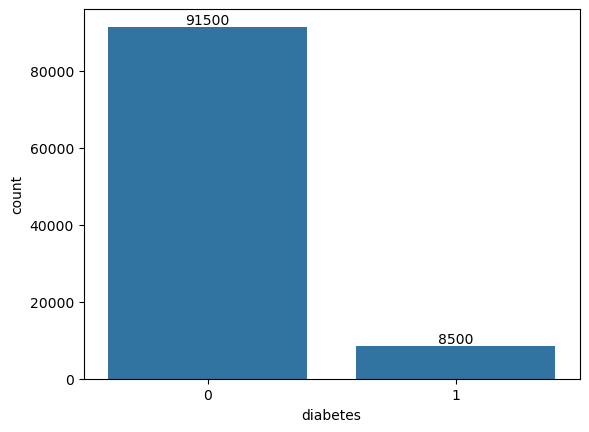

In [11]:
ax = sns.countplot(dataset , x = 'diabetes')
ax.bar_label(ax.containers[0])
plt.show()

In [12]:
# Here IMBalanced Data👆👆

In [13]:
dataset['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

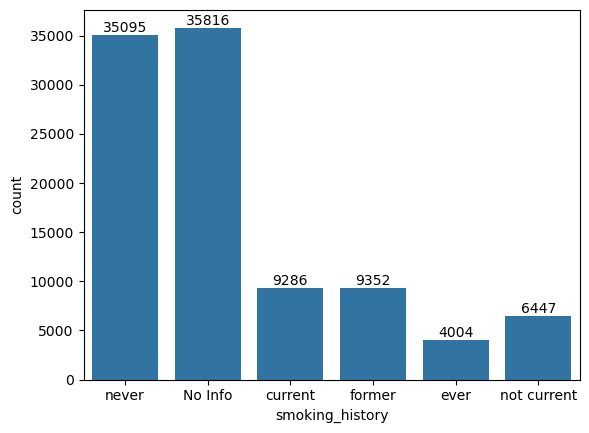

In [14]:
order = ['never', 'No Info', 'current', 'former', 'ever', 'not current']
ax = sns.countplot(data=dataset, x='smoking_history', order=order)
ax.bar_label(ax.containers[0])
plt.show()

---

# 3- Data Prepration

>* Cleaning Data

In [15]:
dataset.drop_duplicates(inplace=True)
dataset.duplicated().sum()

np.int64(0)

In [16]:
# convert age column from float to integer (int)
dataset['age'] = dataset['age'].astype('int64')

In [17]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  int64  
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 7.3+ MB


In [18]:
dataset.iloc[155,:]

gender                  Female
age                          0
hypertension                 0
heart_disease                0
smoking_history        No Info
bmi                      14.43
HbA1c_level                6.5
blood_glucose_level        160
diabetes                     0
Name: 155, dtype: object

In [19]:
# remove age less than 1
dataset.drop(dataset[dataset['age'] < 1].index, inplace=True)


In [20]:
# check age column
dataset.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,95236.000000,95236.000000,95236.000000,95236.00000,95236.000000,95236.000000,95236.000000
mean,42.183009,0.078342,0.041192,27.41747,5.534313,138.268648,0.089063
std,22.213455,0.268711,0.198736,6.71734,1.073856,40.966900,0.284836
min,1.000000,0.000000,0.000000,10.01000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.55000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.32000,5.800000,140.000000,0.000000
75%,60.000000,0.000000,0.000000,29.93000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.69000,9.000000,300.000000,1.000000


In [21]:
dataset.shape

(95236, 9)

>* Spliting Data

In [22]:
feature = dataset.iloc[:,0:-1]
target = dataset.iloc[:,-1]
target

0        0
1        0
2        0
3        0
4        0
        ..
99994    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 95236, dtype: int64

In [23]:
x_train , x_test , y_train , y_test = train_test_split(feature , target , test_size=0.2 , random_state=42 , stratify=target)
print(x_train.shape)
print(y_train.shape)

print('='*15)

print(x_test.shape)
print(y_test.shape)


(76188, 8)
(76188,)
(19048, 8)
(19048,)


---

# 4- Modeling

* 1- Logistic Regression

In [24]:
ordinal_features = ['smoking_history']
numeric_features = ['age','bmi','HbA1c_level','blood_glucose_level']
smoking_order = [['No Info', 'never', 'former', 'not current', 'ever', 'current']]
categorical_features = ['gender']


In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('smoking', OrdinalEncoder(categories=smoking_order), ordinal_features),
        ('gender', OneHotEncoder(drop='first'), categorical_features)  # drop='first' لتجنب الـ Dummy Variable Trap
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)


In [26]:
pipeline_LR = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(class_weight='balanced'))
])



In [27]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),  # بدون scaling
        ('smoking', OrdinalEncoder(categories=smoking_order), ordinal_features),
        ('gender', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)

* 2- randome foerst

In [28]:
pipe_rf = Pipeline([
    ('prep', preprocessor_tree),
    ('model', RandomForestClassifier(class_weight='balanced'))
])

* 3- XGBoost

In [29]:
count_val = y_train.value_counts()
count_val

diabetes
0    69402
1     6786
Name: count, dtype: int64

In [30]:
ratio = count_val.values[0] / count_val.values[1]
ratio

np.float64(10.227232537577365)

In [31]:
pipe_xgb = Pipeline([
    ('prep', preprocessor_tree),
    ('model', XGBClassifier(scale_pos_weight=ratio))
])

---

# Cross Validation before smothe

In [32]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

scoring = ['recall', 'f1']

for name, pipe in [
    ("Logistic", pipeline_LR),
    ("Random Forest", pipe_rf),
    ("XGBoost", pipe_xgb)
]:
    results = cross_validate(pipe, x_train, y_train, cv=cv, scoring=scoring)
    
    print(f"--- {name} ---")
    print("Recall:", results['test_recall'].mean())
    print("F1:", results['test_f1'].mean())
    print()

--- Logistic ---
Recall: 0.8781314470969642
F1: 0.5795479850215942

--- Random Forest ---
Recall: 0.6805187150014737
F1: 0.7933996778984115

--- XGBoost ---
Recall: 0.8654582964927794
F1: 0.6679992897545848



---

# traning model all train data (all model)

In [33]:
pipeline_LR.fit(x_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('smoking',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'Info',
                                                                              'never',
                                                                              'former',
                                                                              'not '
                                                                              'current',
                                                                              'ever',
                                                                              'current']]),
                                                  ['smoking_history']),
                                                 ('gender',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender'])])),
                ('model', LogisticRegression(class_weight='balanced'))])

In [34]:
pipe_rf.fit(x_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('smoking',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'Info',
                                                                              'never',
                                                                              'former',
                                                                              'not '
                                                                              'current',
                                                                              'ever',
                                                                              'current']]),
                                                  ['smoking_history']),
                                                 ('gender',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender'])])),
                ('model', RandomForestClassifier(class_weight='balanced'))])

In [35]:
pipe_xgb.fit(x_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('smoking',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'Info',
                                                                              'never',
                                                                              'former',
                                                                              'not '
                                                                              'current',
                                                                              'ever',
                                                                              'current']]),
                                                  ['smoking_history']),
                                                 ('gender',
                                                  OneHotEncoder(drop='first'),
                                                  ['gend...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

---

# predicted all model

In [36]:
pred_LR = pipeline_LR.predict(x_test)
pred_LR

array([0, 0, 0, ..., 0, 0, 0])

In [37]:
print(pipeline_LR.score(x_train , y_train))
print(pipeline_LR.score(x_test , y_test))

0.8868981991914737
0.881982360352793


In [38]:
pred_rf = pipe_rf.predict(x_test)
pred_rf

array([0, 0, 0, ..., 0, 0, 0])

In [39]:
print(pipe_rf.score(x_train , y_train))
print(pipe_rf.score(x_test , y_test))

0.9992518506851472
0.9696031079378412


In [40]:
pred_xgb = pipe_xgb.predict(x_test)
pred_xgb

array([0, 0, 0, ..., 0, 0, 0])

In [41]:
print(pipe_xgb.score(x_train , y_train))
print(pipe_xgb.score(x_test , y_test))

0.9327453142227122
0.9160541789164217


---

# 5- Evalution Model before use smoth to imbalance process

>> logistic regression Evalution

In [42]:
print(classification_report(y_test, pred_LR))


              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17352
           1       0.42      0.88      0.57      1696

    accuracy                           0.88     19048
   macro avg       0.70      0.88      0.75     19048
weighted avg       0.94      0.88      0.90     19048



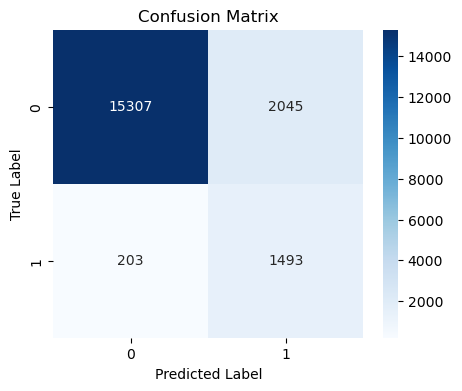

In [43]:
cm = confusion_matrix(y_test, pred_LR)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

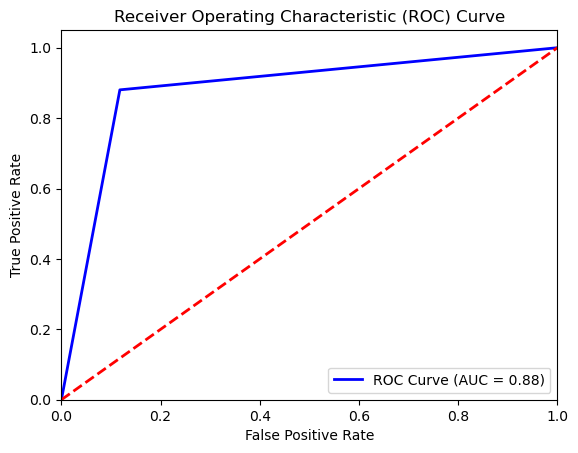

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, pred_LR)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

>> random forest Evalution

In [45]:
print(classification_report(y_test, pred_rf))


              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17352
           1       0.95      0.70      0.80      1696

    accuracy                           0.97     19048
   macro avg       0.96      0.85      0.89     19048
weighted avg       0.97      0.97      0.97     19048



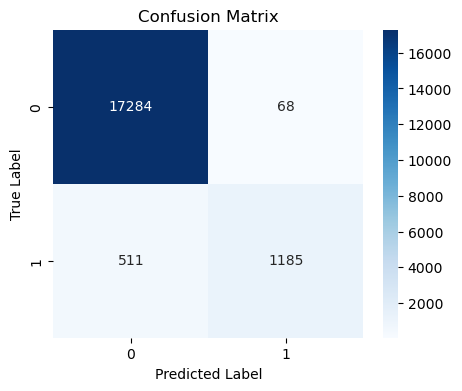

In [46]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

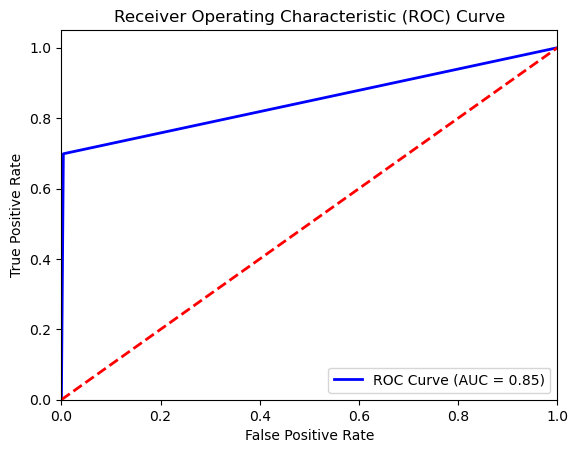

In [47]:
roc_curve(y_test, pred_rf)
fpr, tpr, thresholds = roc_curve(y_test, pred_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

>> XGBoost Evalution

In [48]:
print(classification_report(y_test, pred_xgb))


              precision    recall  f1-score   support

           0       0.99      0.92      0.95     17352
           1       0.52      0.89      0.65      1696

    accuracy                           0.92     19048
   macro avg       0.75      0.90      0.80     19048
weighted avg       0.95      0.92      0.93     19048



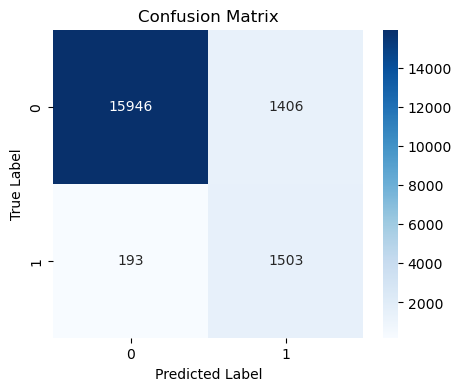

In [49]:
cm = confusion_matrix(y_test, pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

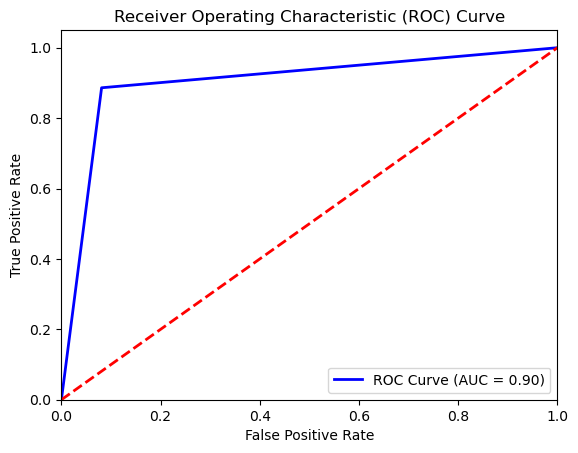

In [50]:
roc_curve(y_test, pred_xgb)
fpr, tpr, thresholds = roc_curve(y_test, pred_xgb)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

---

# build modeling and Evalution model after use smoth to imbalance process

In [51]:
# smote = SMOTE(k_neighbors=3,sampling_strategy='auto', random_state=42)

* 1- Logistic Regression

In [52]:
pipeline_LR2 = ImbPipeline(steps=[
    ('preprocessing', clone(preprocessor)),
    ('smoth', SMOTE(k_neighbors=3,sampling_strategy='auto', random_state=42)),
    ('model', LogisticRegression())
])
#    ('preprocessing', clone(preprocessor)),
#   عشان مايروح يدرب كمان مرة علي نفس البياناتprocessor مهمة هادي لانو بروح يعمل نسخة من ال
# setting بعمل نسخة جديدة بنفس ال 

* 2- randome foerst

In [53]:
pipe_rf2 = ImbPipeline([
    ('prep', clone(preprocessor_tree)),
    ('smoth', SMOTE(k_neighbors=3,sampling_strategy='auto', random_state=42)),
    ('model', RandomForestClassifier())
])

* 3- XGBoost

In [54]:
pipe_xgb2 = ImbPipeline([
    ('prep', clone(preprocessor_tree)),
    ('smoth', SMOTE(k_neighbors=3,sampling_strategy='auto', random_state=42)),
    ('model', XGBClassifier())
])

---

# Cross Validation after smothe

In [55]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

scoring = ['recall', 'f1']

for name, pipe in [
    ("Logistic", pipeline_LR2),
    ("Random Forest", pipe_rf2),
    ("XGBoost", pipe_xgb2)
]:
    results = cross_validate(pipe, x_train, y_train, cv=cv, scoring=scoring)
    
    print(f"--- {name} ---")
    print("Recall:", results['test_recall'].mean())
    print("F1:", results['test_f1'].mean())
    print()

--- Logistic ---
Recall: 0.8768051871500148
F1: 0.5804125136376905

--- Random Forest ---
Recall: 0.6976127320954907
F1: 0.7809499782046275

--- XGBoost ---
Recall: 0.6954022988505747
F1: 0.7980741368507106



---

*  10- traning all model with smothe & predicted


1- logistic regression


In [56]:
pipeline_LR2.fit(x_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('smoking',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'Info',
                                                                              'never',
                                                                              'former',
                                                                              'not '
                                                                              'current',
                                                                              'ever',
                                                                              'current']]),
                                                  ['smoking_history']),
                                                 ('gender',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender'])])),
                ('smoth', SMOTE(k_neighbors=3, random_state=42)),
                ('model', LogisticRegression())])

2- random forest

In [57]:
pipe_rf2.fit(x_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('smoking',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'Info',
                                                                              'never',
                                                                              'former',
                                                                              'not '
                                                                              'current',
                                                                              'ever',
                                                                              'current']]),
                                                  ['smoking_history']),
                                                 ('gender',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender'])])),
                ('smoth', SMOTE(k_neighbors=3, random_state=42)),
                ('model', RandomForestClassifier())])

3- XGBoost

In [58]:

pipe_xgb2.fit(x_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('smoking',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'Info',
                                                                              'never',
                                                                              'former',
                                                                              'not '
                                                                              'current',
                                                                              'ever',
                                                                              'current']]),
                                                  ['smoking_history']),
                                                 ('gender',
                                                  OneHotEncoder(drop='first'),
                                                  ['gend...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

---

predection all model

In [59]:
y_pred_lr2 = pipeline_LR2.predict(x_test)
y_pred_lr2


array([0, 0, 0, ..., 0, 0, 0])

In [60]:
print(pipeline_LR2.score(x_train , y_train))
print(pipeline_LR2.score(x_test , y_test))

0.8874888433874101
0.882297354052919


In [61]:
y_pred_rf2 = pipe_rf2.predict(x_test)
y_pred_rf2

array([0, 0, 0, ..., 0, 0, 0])

In [62]:
print(pipe_rf2.score(x_train , y_train))
print(pipe_rf2.score(x_test , y_test))

0.9992649761117236
0.9670831583368332


In [63]:
y_pred_xg2 = pipe_xgb2.predict(x_test)
y_pred_xg2

array([0, 0, 0, ..., 0, 0, 0])

In [64]:
print(pipe_xgb2.score(x_train , y_train))
print(pipe_xgb2.score(x_test , y_test))

0.9744054181760907


0.9692881142377152


---

* 11- Evalution Model after use smote

1- logistic regression after apply smaoth

In [65]:
print(classification_report(y_test, y_pred_lr2))


              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17352
           1       0.42      0.88      0.57      1696

    accuracy                           0.88     19048
   macro avg       0.70      0.88      0.75     19048
weighted avg       0.94      0.88      0.90     19048



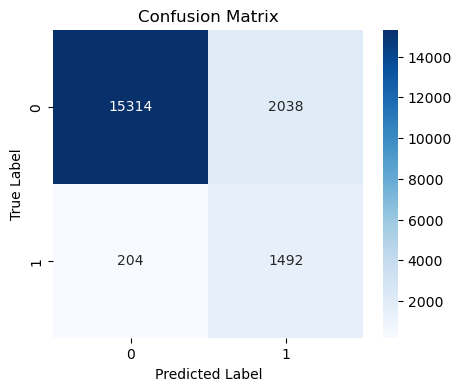

In [66]:
cm = confusion_matrix(y_test, y_pred_lr2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

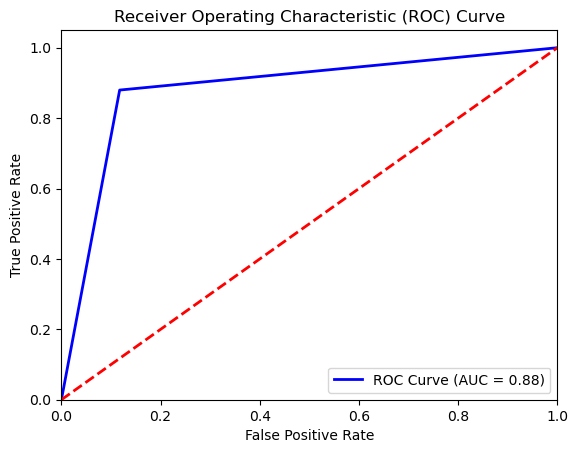

In [67]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr2)
roc_auc = auc(fpr, tpr)


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

2- random forest after apply smaoth

In [68]:
print(classification_report(y_test, y_pred_rf2))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17352
           1       0.89      0.72      0.80      1696

    accuracy                           0.97     19048
   macro avg       0.93      0.86      0.89     19048
weighted avg       0.97      0.97      0.97     19048



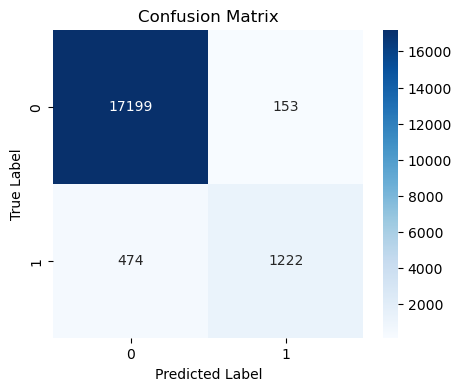

In [69]:
cm = confusion_matrix(y_test, y_pred_rf2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

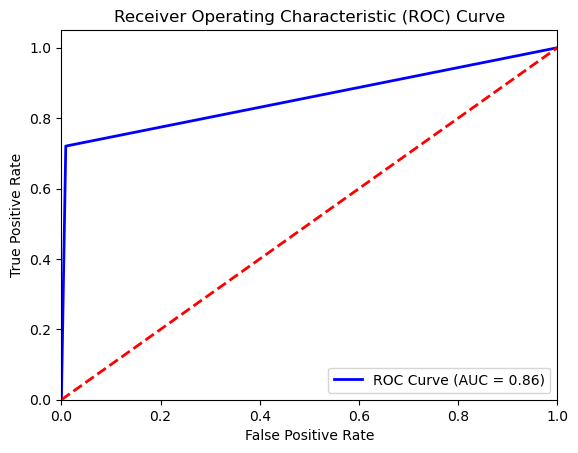

In [70]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_rf2)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])    
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

3- XGBoost after apply smaoth

In [71]:
print(classification_report(y_test, y_pred_xg2))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17352
           1       0.93      0.71      0.80      1696

    accuracy                           0.97     19048
   macro avg       0.95      0.85      0.89     19048
weighted avg       0.97      0.97      0.97     19048



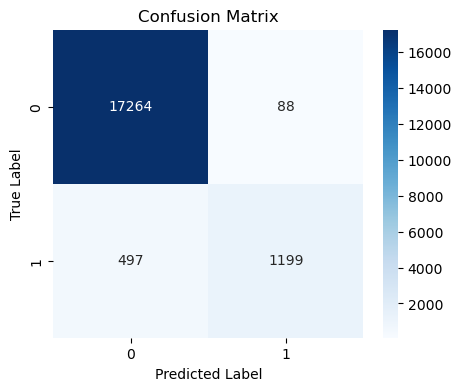

In [72]:
cm = confusion_matrix(y_test, y_pred_xg2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

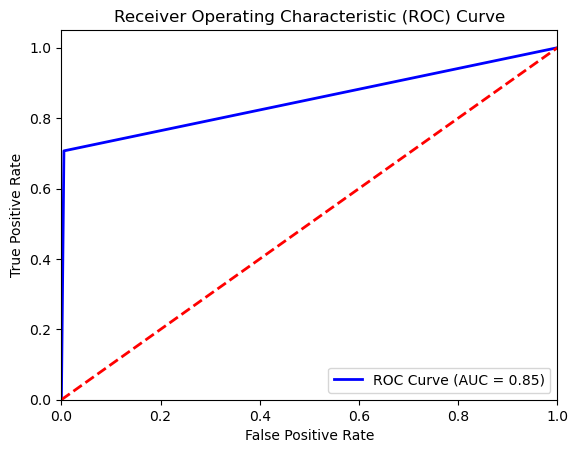

In [73]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xg2)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

---

* 10- hyperparamater tuning for model before useing smothe


1-  hyperparamater tuning Logistic regression before smoth

In [74]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

In [75]:
grid_lr = GridSearchCV(pipeline_LR, param_grid, cv=5, scoring='f1')
grid_lr.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'bmi',
                                                                          'HbA1c_level',
                                                                          'blood_glucose_level']),
                                                                        ('smoking',
                                                                         OrdinalEncoder(categories=[['No '
                                                                                                     'Info',
                                                                                                     'never',
                                                                                                     'former',
                                                                                                     'not '
                                                                                                     'current',
                                                                                                     'ever',
                                                                                                     'current']]),
                                                                         ['smoking_history']),
                                                                        ('gender',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['gender'])])),
                                       ('model',
                                        LogisticRegression(class_weight='balanced'))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__penalty': ['l2'], 'model__solver': ['lbfgs']},
             scoring='f1')

In [76]:
best_model_lr1 = grid_lr.best_estimator_
y_pred_lr_1 = best_model_lr1.predict(x_test)
y_pred_lr_1

array([0, 0, 0, ..., 0, 0, 0])

2-  hyperparamater tuning random forest before smoth

In [77]:
param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

In [78]:
grid_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring='f1')
grid_rf.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['age',
                                                                          'bmi',
                                                                          'HbA1c_level',
                                                                          'blood_glucose_level']),
                                                                        ('smoking',
                                                                         OrdinalEncoder(categories=[['No '
                                                                                                     'Info',
                                                                                                     'never',
                                                                                                     'former',
                                                                                                     'not '
                                                                                                     'current',
                                                                                                     'ever',
                                                                                                     'current']]),
                                                                         ['smoking_history']),
                                                                        ('gender',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['gender'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced'))]),
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [79]:
best_model_rf1 = grid_rf.best_estimator_
y_pred_rf_1 = best_model_rf1.predict(x_test)
y_pred_rf_1

array([0, 0, 0, ..., 0, 0, 0])

3-  hyperparamater tuning XGBoost before smoth

In [80]:
param_xgb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5, 7]
}

In [81]:
grid_xgb = GridSearchCV(pipe_xgb, param_xgb, cv=5, scoring='f1')
grid_xgb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['age',
                                                                          'bmi',
                                                                          'HbA1c_level',
                                                                          'blood_glucose_level']),
                                                                        ('smoking',
                                                                         OrdinalEncoder(categories=[['No '
                                                                                                     'Info',
                                                                                                     'never',
                                                                                                     'former',
                                                                                                     'not '
                                                                                                     'current',
                                                                                                     'ever',
                                                                                                     'current']]),
                                                                         ['smoking_history']),
                                                                        ('gender',
                                                                         OneHot...
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             param_grid={'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [82]:
best_model_xgb1 = grid_xgb.best_estimator_
y_pred_xgb_1 = best_model_xgb1.predict(x_test)
y_pred_xgb_1

array([0, 0, 0, ..., 0, 0, 0])

---

* Evalution model with new paramater (before smoth)

logistic regression

In [83]:
print(best_model_lr1.score(x_train , y_train))
print(best_model_lr1.score(x_test , y_test))

0.8868981991914737
0.881982360352793


In [84]:
print(accuracy_score(y_test ,y_pred_lr_1 ))

0.881982360352793


In [85]:
print(classification_report(y_test, y_pred_lr_1))


              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17352
           1       0.42      0.88      0.57      1696

    accuracy                           0.88     19048
   macro avg       0.70      0.88      0.75     19048
weighted avg       0.94      0.88      0.90     19048



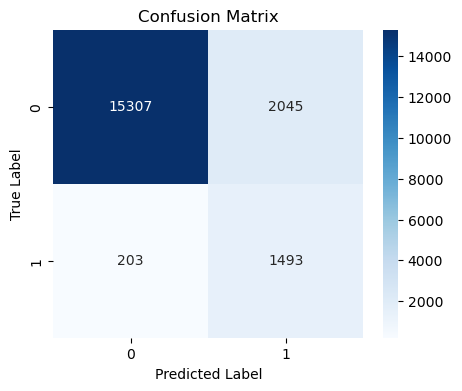

In [86]:
cm = confusion_matrix(y_test, y_pred_lr_1)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

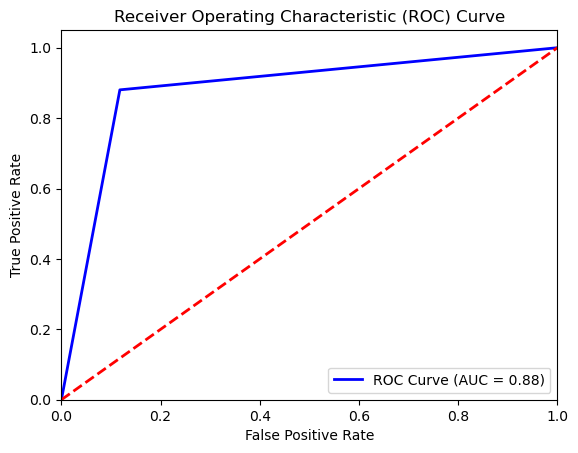

In [87]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr_1)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])    
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

random forest

In [88]:
print(best_model_rf1.score(x_train , y_train))
print(best_model_rf1.score(x_test , y_test))

0.9992255998319945
0.9693406131877362


In [89]:
print(accuracy_score(y_test ,y_pred_rf_1 ))

0.9693406131877362


In [90]:
print(classification_report(y_test, y_pred_rf_1))


              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17352
           1       0.94      0.70      0.80      1696

    accuracy                           0.97     19048
   macro avg       0.96      0.85      0.89     19048
weighted avg       0.97      0.97      0.97     19048



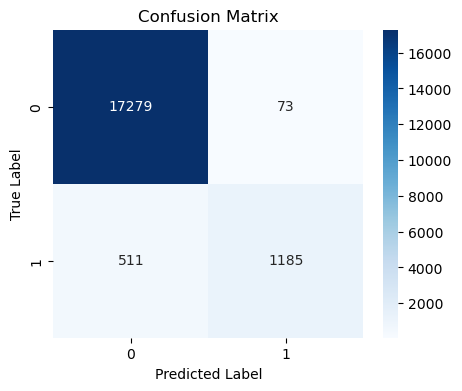

In [91]:
cm = confusion_matrix(y_test, y_pred_rf_1)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

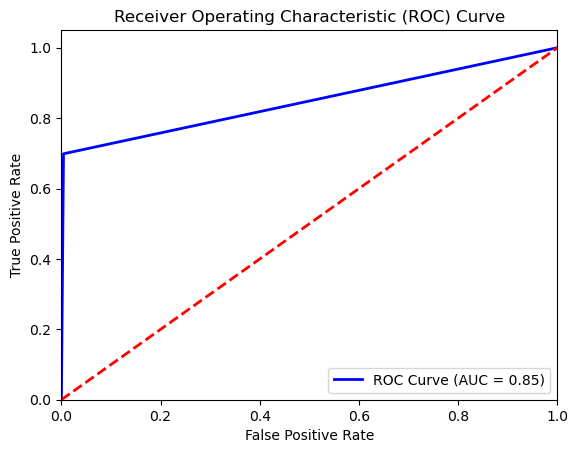

In [92]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_rf_1)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

XGBooast

In [93]:
print(accuracy_score(y_test ,y_pred_xgb_1 ))

0.9137967240655187


In [94]:
print(best_model_xgb1.score(x_train , y_train))
print(best_model_xgb1.score(x_test , y_test))

0.9286764319840395
0.9137967240655187


In [95]:
print(classification_report(y_test, y_pred_xgb_1))


              precision    recall  f1-score   support

           0       0.99      0.92      0.95     17352
           1       0.51      0.90      0.65      1696

    accuracy                           0.91     19048
   macro avg       0.75      0.91      0.80     19048
weighted avg       0.95      0.91      0.92     19048



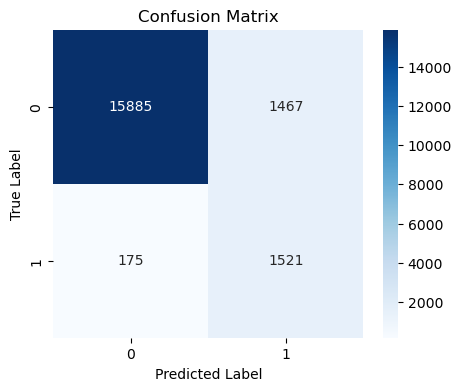

In [96]:
cm = confusion_matrix(y_test, y_pred_xgb_1)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

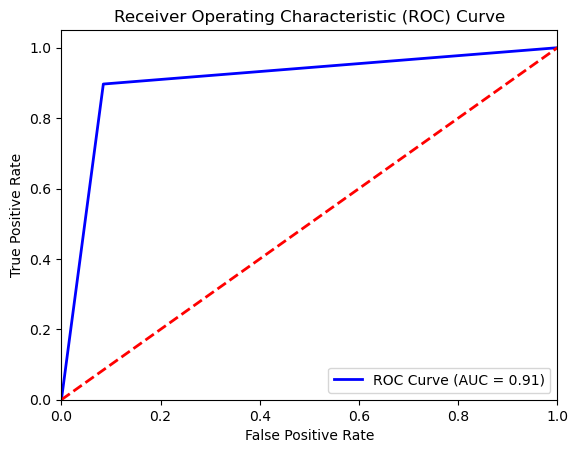

In [97]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb_1)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

---

* 11- hyperparamater tuning for model after useing smothe


In [98]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

In [99]:
grid_lr2 = GridSearchCV(pipeline_LR2, param_grid, cv=5, scoring='f1')
grid_lr2.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'bmi',
                                                                          'HbA1c_level',
                                                                          'blood_glucose_level']),
                                                                        ('smoking',
                                                                         OrdinalEncoder(categories=[['No '
                                                                                                     'Info',
                                                                                                     'never',
                                                                                                     'former',
                                                                                                     'not '
                                                                                                     'current',
                                                                                                     'ever',
                                                                                                     'current']]),
                                                                         ['smoking_history']),
                                                                        ('gender',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['gender'])])),
                                       ('smoth',
                                        SMOTE(k_neighbors=3, random_state=42)),
                                       ('model', LogisticRegression())]),
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__penalty': ['l2'], 'model__solver': ['lbfgs']},
             scoring='f1')

In [100]:
best_model_lr2 = grid_lr2.best_estimator_
y_pred_lr_2 = best_model_lr2.predict(x_test)
y_pred_lr_2

array([0, 0, 0, ..., 0, 0, 0])

In [101]:
param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

In [102]:
grid_rf2 = GridSearchCV(pipe_rf2, param_rf, cv=5, scoring='f1')
grid_rf2.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['age',
                                                                          'bmi',
                                                                          'HbA1c_level',
                                                                          'blood_glucose_level']),
                                                                        ('smoking',
                                                                         OrdinalEncoder(categories=[['No '
                                                                                                     'Info',
                                                                                                     'never',
                                                                                                     'former',
                                                                                                     'not '
                                                                                                     'current',
                                                                                                     'ever',
                                                                                                     'current']]),
                                                                         ['smoking_history']),
                                                                        ('gender',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['gender'])])),
                                       ('smoth',
                                        SMOTE(k_neighbors=3, random_state=42)),
                                       ('model', RandomForestClassifier())]),
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [103]:
best_model_rf2 = grid_rf2.best_estimator_
y_pred_rf_2 = best_model_rf2.predict(x_test)
y_pred_rf_2

array([0, 0, 0, ..., 0, 0, 0])

In [104]:
param_xgb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5, 7]
}

In [105]:
grid_xgb2 = GridSearchCV(pipe_xgb2, param_xgb, cv=5, scoring='f1')
grid_xgb2.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('num',
                                                                         'passthrough',
                                                                         ['age',
                                                                          'bmi',
                                                                          'HbA1c_level',
                                                                          'blood_glucose_level']),
                                                                        ('smoking',
                                                                         OrdinalEncoder(categories=[['No '
                                                                                                     'Info',
                                                                                                     'never',
                                                                                                     'former',
                                                                                                     'not '
                                                                                                     'current',
                                                                                                     'ever',
                                                                                                     'current']]),
                                                                         ['smoking_history']),
                                                                        ('gender',
                                                                         OneHot...
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             param_grid={'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [106]:
best_model_xgb2 = grid_xgb2.best_estimator_
y_pred_xgb_2 = best_model_xgb2.predict(x_test)
y_pred_xgb_2

array([0, 0, 0, ..., 0, 0, 0])

---

Evalution each model after smoth

logistic after smoth

In [107]:
print(accuracy_score(y_test ,y_pred_lr_2 ))

0.8824548509029819


In [108]:
print(classification_report(y_test, y_pred_lr_2))


              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17352
           1       0.42      0.88      0.57      1696

    accuracy                           0.88     19048
   macro avg       0.70      0.88      0.75     19048
weighted avg       0.94      0.88      0.90     19048



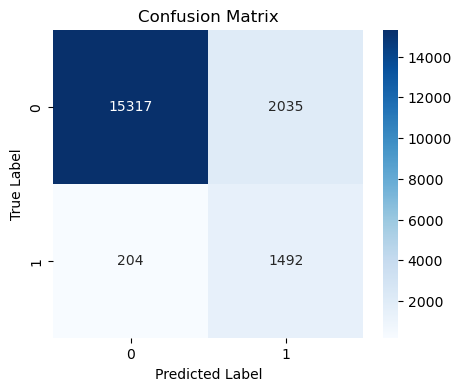

In [109]:
cm = confusion_matrix(y_test, y_pred_lr_2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

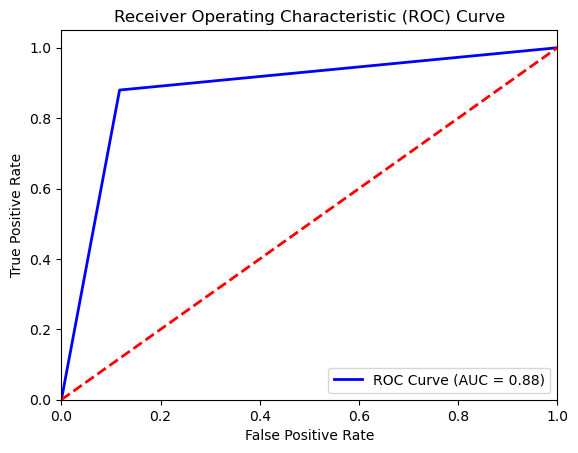

In [110]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_lr_2)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

random forest after smoth

In [111]:
print(accuracy_score(y_test ,y_pred_rf_2 ))

0.9682906341873162


In [112]:
print(classification_report(y_test, y_pred_rf_2))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17352
           1       0.91      0.72      0.80      1696

    accuracy                           0.97     19048
   macro avg       0.94      0.86      0.89     19048
weighted avg       0.97      0.97      0.97     19048



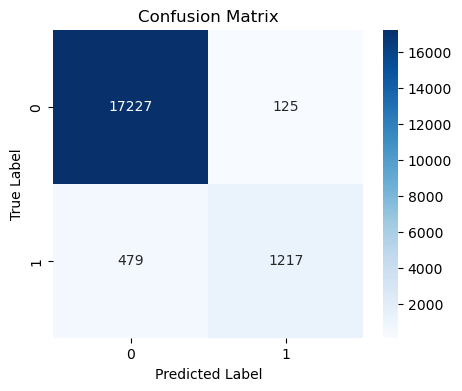

In [113]:
cm = confusion_matrix(y_test, y_pred_rf_2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

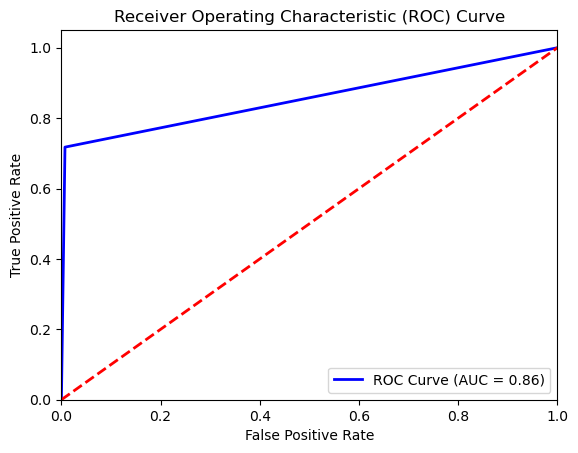

In [114]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_rf_2)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

____


In [115]:
y_proba = best_model_rf2.predict_proba(x_test)
y_proba

array([[0.99875   , 0.00125   ],
       [1.        , 0.        ],
       [0.98958333, 0.01041667],
       ...,
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ]])

In [116]:
# the best performance
y_proba = best_model_xgb2.predict_proba(x_test)[:, 1]
y_proba
y_pred_custom = (y_proba >= 0.4).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17352
           1       0.88      0.73      0.80      1696

    accuracy                           0.97     19048
   macro avg       0.93      0.86      0.89     19048
weighted avg       0.97      0.97      0.97     19048



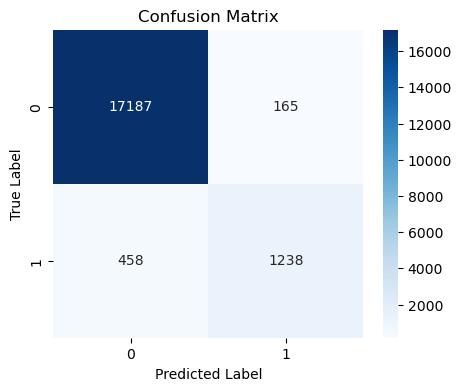

In [117]:
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

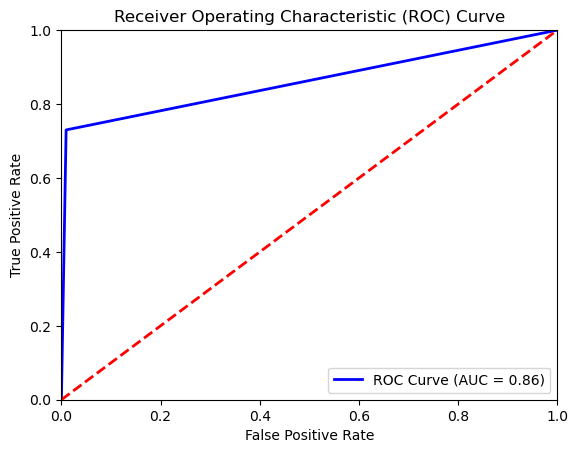

In [118]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_custom)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

___

XGBoost after smoth

In [119]:
print(accuracy_score(y_test ,y_pred_xgb_2))

0.9701280974380513


In [120]:
print(classification_report(y_test, y_pred_xgb_2))


              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17352
           1       0.95      0.70      0.81      1696

    accuracy                           0.97     19048
   macro avg       0.96      0.85      0.90     19048
weighted avg       0.97      0.97      0.97     19048



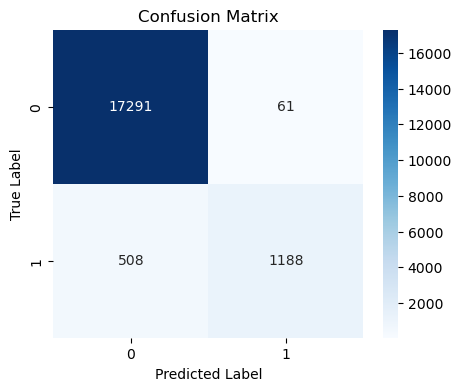

In [121]:
cm = confusion_matrix(y_test, y_pred_xgb_2)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show() 

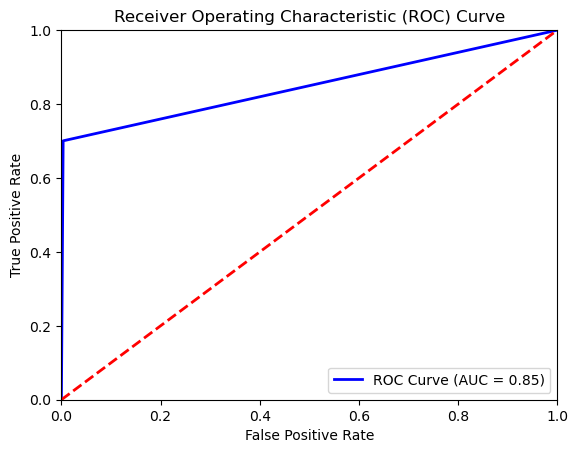

In [122]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb_2)
roc_auc = auc(fpr, tpr) 

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


---

* > draw shap for best Model (best_model_rf2)

In [123]:
rf_model = best_model_rf2.named_steps['model']
rf_model

RandomForestClassifier(min_samples_split=5, n_estimators=200)

In [124]:
X_test_transformed = best_model_rf2.named_steps['prep'].transform(x_test)
X_test_transformed

array([[58.  , 32.48,  5.8 , ...,  0.  ,  1.  ,  0.  ],
       [ 2.  , 15.81,  4.5 , ...,  0.  ,  0.  ,  0.  ],
       [32.  , 22.5 ,  5.7 , ...,  0.  ,  0.  ,  0.  ],
       ...,
       [60.  , 19.42,  6.2 , ...,  0.  ,  0.  ,  0.  ],
       [48.  , 35.49,  4.  , ...,  0.  ,  0.  ,  0.  ],
       [16.  , 19.22,  6.6 , ...,  0.  ,  0.  ,  0.  ]])

In [125]:
feature_names = best_model_rf2.named_steps['prep'].get_feature_names_out()
clean_names = [col.split("__")[1] for col in feature_names]
clean_names

['age',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'smoking_history',
 'gender_Male',
 'gender_Other',
 'hypertension',
 'heart_disease']

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12660\3395570068.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


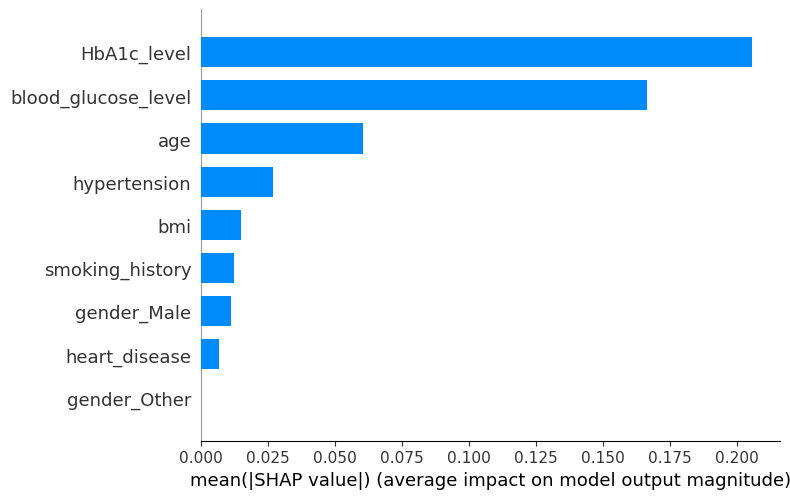

'\n"SHAP values were computed on a stratified random sample of 2,000 test instances (random_state=42) using TreeExplainer,\n which provides exact Shapley values derived from the model structure rather than approximations."\n\n'

In [133]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_transformed), size=2000, replace=False)
X_shap_sample = X_test_transformed[sample_idx]

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

shap.summary_plot(
    shap_values[:, :, 1],
    X_shap_sample,
    feature_names=clean_names,
    plot_type="bar"
)
# Because TreeExplainer calculates SHAP values ​​from the tree structure itself, rather than from the data.(becouse 2000 sample)

'''
"SHAP values were computed on a stratified random sample of 2,000 test instances (random_state=42) using TreeExplainer,
 which provides exact Shapley values derived from the model structure rather than approximations."

'''

In [127]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

<class 'numpy.ndarray'>
(100, 9, 2)


----

saved model

In [128]:

joblib.dump(best_model_rf2, 'diabetes_model.pkl')


['diabetes_model.pkl']

---

* prepare data to train DNN model (save clean data)

In [129]:
prep = clone(preprocessor)
prep.fit(x_train)


X_train_transformed = prep.transform(x_train)
X_test_transformed  = prep.transform(x_test)

smote = SMOTE(k_neighbors=3, random_state=42,sampling_strategy='auto')
X_train_final, y_train_final = smote.fit_resample(X_train_transformed, y_train)


np.save('X_train_processed.npy', X_train_final)
np.save('X_test_processed.npy',  X_test_transformed)
np.save('y_train.npy',           y_train_final)
np.save('y_test.npy',            y_test.values)



In [130]:
print(f"before SMOTE: {X_train_transformed.shape[0]}")
print(f"after SMOTE: {X_train_final.shape[0]}")

before SMOTE: 76188
after SMOTE: 138804


In [131]:
# X_train = np.load('X_train_processed.npy')
# X_test  = np.load('X_test_processed.npy')
# y_train = np.load('y_train.npy')
# y_test  = np.load('y_test.npy')

# print(X_train.shape)
# print(X_test.shape)